---
# Exemples de réduction de la dimensionnalité en apprentissage non supervisé
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/189bb058-f84c-49bb-bfb1-2d0d4d473e20.gif"  width="500" />
    <div>
    <font size="1.5">Image Source: https://blog.roboflow.com/what-is-dimensionality-reduction//</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous allons voir quelques exemples de réduction de dimensionnalité appliqués à des images de chiffres. 

## Table des matières
1. Le b.a.-ba des méthodes de projections
2. Exemples de méthodes de réduction de la dimensionnalité
    1. Lecture et affichage des données
    2. Analyse en composantes principales
    3. Encodage localement linéaire
    4. Isomap
    5. t-SNE
    6. UMAP
3. Applications
    1. Déroulement d'un rouleau suisse
    2. Aplatissement d'une sphère manquant un quartier

#### Importation des librairies utilisées.

In [1]:
from sklearn.utils import check_random_state
from sklearn import (
    manifold,
    datasets,
    decomposition,
    ensemble,
    discriminant_analysis,
    random_projection,
)

from collections import OrderedDict
from functools import partial
from time import time
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import NullFormatter
import umap

import numpy as np
import matplotlib.pyplot as plt
figure = {"dpi": 200, "figsize": [5, 2.5]}
plt.rc("figure", **figure)
plt.style.use('dark_background')

import warnings
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden")


Axes3D

seed = 42
np.random.seed(seed)

%matplotlib inline

La réduction de la dimensionnalité consiste à prendre des données dans un espace de grande dimension, et à les
transformer en données dans un espace de plus petite dimension. Le défi consiste à conserver le maximum d’information
partagée entre les données lors de la transformation. Ainsi, les données en sortie, plus petites, pourront
être traitées plus rapidement et plus efficacement avec nos algorithmes d’analyse et de traitement.
Les applications sont multiples en classification, régression et regroupement des données (*Data Clustering*).

Une des raisons pour lesquelles la réduction de la dimensionnalité est si importante est liée au fait
que les algorithmes performent mal avec des données en haute dimension. Le problème est connu sous le nom du
[fléau de la dimension](https://fr.wikipedia.org/wiki/Fléau_de_la_dimension#:~:text=Le_fléau_de_la_dimension_ou_malédiction_de,pas_lieu_dans_des_espaces_dimension_moindre.)
 (*Curse of Dimensionnality*).

On ne peut pas simplement enlever plusieurs des dimensions d'un ensemble de données afin de réduire la dimension
finale de celles-ci. La figure suivante montre ce qu'il arrive lorsqu'on projette une surface 3-D sur une surface 2-D en éliminant une composante à la fois. Chaque objet en bois se transforme en différentes lettres selon la direction de projection! Il y a beaucoup d'information perdue à chaque fois qu'on élimine une des dimensions.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/godel-escher-bach.jpeg"  width="250" />
    <div>
    <font size="0.5">Image Source: https://emergentbydesign.com/2012/04/16/what-are-the-most-life-changing-books-youve-read-twitter-poll//</font>
    </div>
</div>
<p>&nbsp;</p>

Plusieurs méthodes de réduction de la dimensionnalité procèdent de façon plus astucieuse. On transforme d'abord
l'ensemble de données initial $X=[x_{1}, \cdots, x_{N}]$ en un nouvel ensemble $Y=[y_{1}, \cdots, y_{N}]$ où
la majorité de l'information est contenue dans les premières composantes; $y_{1}, y_{2}$ par exemple. Idéalement,
les points voisins dans l'espace de départ devraient rester voisins dans l'espace d'arrivée. Puis, on ne garde que les $M$ premières composantes du vecteur transformé, soit $Y=[y_{1}, \cdots, y_{M}]$ avec $M<<N$. La valeur de $M$ est déterminée  selon la méthode utilisée.

Le panneau gauche de la figure suivante montre un exemple 3-D où les données occupent les trois dimensions, mais sont
regroupées sur une surface de plus petite dimension (*Manifold*), dans ce cas-ci un plan. Le panneau de droite
montre le résultat de la réduction de la dimensionnalité. Dans cet exemple, on a utilisé
l'[analyse en composantes principales (ACP)](https://fr.wikipedia.org/wiki/Analyse_en_composantes_principales) 
pour transformer les données. C'est une des méthodes présentées dans ce module. Notez comme
le bruit dans les données a été réduit en passant de 3-D en 2-D; cela faciliterait
par exemple la classification des quatre nuages de points.

Les méthodes précédentes sont linéaires; elles projettent les données d'un espace N-D vers un autre espace N-D, plus pratique, puis en extraient un sous-ensemble de $M$ variables. Les méthodes non linéaires sont encore plus astucieuses. Elles transforment directement un espace N-D en un autre M-D avec $M<<N$; ce n'est pas une projection, mais plutôt un plongement (*Data Embedding*). Les deux types de méthodes sont présentés dans le module.

<p>&nbsp;</p>
<div align="center">
    <img src="./images/pca-illustration.png"  width="700" />
    <div>
    <font size="0.5">Image Source: http://phdthesis-bioinformatics-maxplanckinstitute-molecularplantphys.matthias-scholz.de/</font>
    </div>
</div>
<p>&nbsp;</p>

## Le b.a.-ba des méthodes de projections

Dans la section suivante, nous allons utiliser la réduction de la dimensionnalité afin de regrouper
ensemble des images similaires de dimension 8x8. C'est une application simple qui permet de bien comprendre l'idée
derrière la méthode.

Supposons que nous avons un ensemble d'images telles que chacune correspond à un point dans un espace de
dimension $8\times8=64$. Il est évidemment impossible de visualiser la distribution des images sous cette forme.
On peut toutefois réduire la dimensionnalité de l'espace afin de le projeter dans un sous-espace de dimension 2. C'est
nettement plus pratique!

Parler de projeter une image dans un espace 2-D (deux dimensions) est évidemment un abus de langage.
Cela veut simplement dire que pour chaque image, prenons celle d'un 4 par exemple, on transforme ses coordonnées de
64-D à 2-D, puis on affiche le symbole 4 à la position 2-D dans le plan. On ne s'intéresse
pas à une déformation quelconque de l'image du 4, mais uniquement à sa position finale dans l'espace d'arrivée en 2-D.

Il existe de nombreuses méthodes de projection produisant des résultats souvent
très différents. Nous allons en décrire plusieurs. Idéalement, les chiffres similaires
devraient tous être regroupés ensemble, sans superposition avec d'autres chiffres, dans le plan 2-D.

Plusieurs des méthodes sont linéaires et d'autres sont non linéaires. Qu'est-ce que ça veut dire? Commençons
par les méthodes linéaires. Transformons une image, par exemple le chiffre 4 précédent, en
un vecteur $X$ en 64-D. Une projection linéaire transformera le vecteur $X$ en un nouveau vecteur $Y$ en 64-D
selon

$$\bf{y} =  \bf{M} \bf{x}$$
avec

$$\bf{M} = \begin{pmatrix} m_{1,1} & m_{1,2} & \cdots & x_{1,64} \\
\vdots & &  &   \vdots \\
m_{64,1} & x_{64,2} & \cdots & x_{64,64} &  \end{pmatrix},
\bf{x} =\begin{pmatrix} x_{1} \\ x_{2} \\ \vdots \\ x_{64}  \end{pmatrix},
     \bf{y} =\begin{pmatrix} y_{1} \\ y_{2} \\ \vdots \\ y_{64}  \end{pmatrix}.$$
L'étape suivante consiste à ne garder que les deux premières valeurs du vecteur transformé $Y$. L'affichage des
points $(y_{1},y_{2})$ dans le plan produira plusieurs des figures qui suivent. Pour chaque méthode de réduction de
dimensionnalité, le secret de la sauce est dans les coefficients de la matrice de transformation $M$.

Les méthodes non linéaires ne sont pas basées sur des combinaisons
linéaires des composantes $x_{i}$. Elles sont plus complexes et généralement itératives. C'est-à-dire, qu'il n'existe pas de
relation simple entre les composantes $x_{i}$ et $y_{i}$. Difficile d'être plus simple sans aller dans les détails.

Les méthodes linéaires ont été les premières utilisées, car on peut les dériver analytiquement. Les méthodes
non linéaires, généralement plus performantes, ont émergé des travaux
sur les réseaux de neurones et ont été mises en pratique grâce à la puissance de calcul des ordinateurs.

Plusieurs méthodes sont présentées dans ce qui suit. Les méthodes linéaires sont présentées en premier.
Les méthodes non linéaires suivent ensuite. Elles donnent généralement de
meilleurs résultats que les premières, mais sont plus gourmandes en mémoire et temps de calcul.

## Exemples de méthodes de réduction de la dimensionnalité

Cette partie est inspirée des
[exemples de code](https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html#sphx-glr-auto-examples-manifold-plot-lle-digits-py)
de la librairie Scikit-learn.

#### Lecture et affichage des données

Nous allons utiliser un sous-ensemble du jeu de données
[**MNIST**](https://en.wikipedia.org/wiki/MNIST_database)
qui comprend des images de chiffres 0 à 9 de taille $8 \text{ par } 8$. Les images du jeu de données original sont de taille $28 \text{ par } 28$. Nous allons n'utiliser que les images des chiffres 0 à 5.

In [2]:
digits = datasets.load_digits(n_class=6)
X = digits.data
y = digits.target
n_samples, n_features = X.shape
n_neighbors = 30
n_components = 2

Exemples d'images de chiffres 0 à 5.

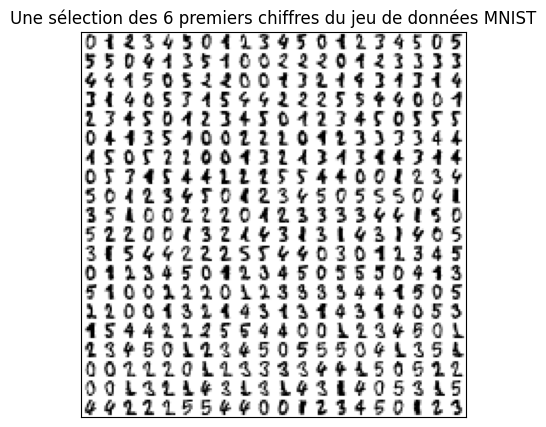

In [3]:
with plt.style.context('default'):
    fig = plt.figure(figsize=[5, 5])

    n_img_per_row = 20
    img = np.zeros((10 * n_img_per_row, 10 * n_img_per_row))
    for i in range(n_img_per_row):
        ix = 10 * i + 1
        for j in range(n_img_per_row):
            iy = 10 * j + 1
            img[ix : ix + 8, iy : iy + 8] = X[i * n_img_per_row + j].reshape((8, 8))

    plt.xticks([])
    plt.yticks([])
    plt.title('Une sélection des 6 premiers chiffres du jeu de données MNIST');

plt.imshow(img, cmap=plt.cm.binary)

Le code ci-dessous sert à afficher les graphiques pour les exemples de projection qui suivent.

In [4]:
from IPython.display import display

def plot_embedding(X_emb, y, title=None, figsize=(3, 3), cmap=plt.cm.Set1):
    x_min, x_max = 1.1 * np.min(X_emb, 0), 1.1 * np.max(X_emb, 0)
    X_norm = (X_emb - x_min) / (x_max - x_min)

    plt.figure(figsize=figsize)
    ax = plt.subplot(111)

    for i in range(X_norm.shape[0]):
        ax.text(
            X_norm[i, 0],
            X_norm[i, 1],
            str(y[i]),
            color=cmap((y[i] + 1) / 10.0),
            fontdict={'weight': 'bold', 'size': 4},
        )

    ax.set_xticks([])
    ax.set_yticks([])

    if title is not None:
        plt.title(title, fontsize=10)

    display(plt.gcf())
    plt.close()


### Analyse en composantes principales

L'analyse en composantes principales (*Principal Components Analysis* ou *PCA*) est une méthode linéaire classique qui consiste à transformer des variables $x_i$ corrélées entre elles (c.-à-d. liées) en nouvelles variables $y_i$ décorrélées les unes des autres. Les nouvelles variables sont nommées « composantes principales ». Elles sont ordonnées en ordre décroissant d'importance (mesurée par leur variance) selon

$$\sigma^2(y_1)>\sigma^2(y_2)>\cdots \sigma^2(y_{N})$$

Lorsqu'on veut compresser un ensemble de $N$ variables aléatoires, les $M$ premiers axes de l'analyse en composantes principales sont un meilleur choix, du point de vue de la variance.

La figure suivante montre les deux premiers axes principaux.

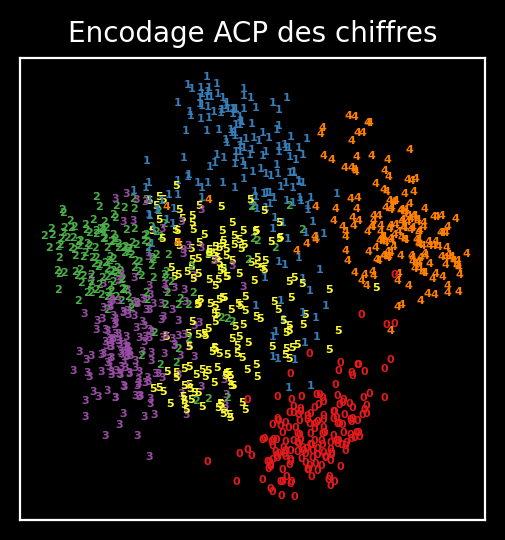

CPU times: user 917 ms, sys: 15.8 ms, total: 933 ms
Wall time: 593 ms


In [5]:
%%time
pca = decomposition.PCA(n_components=n_components, random_state=seed)
X_pca = pca.fit_transform(X)

plot_embedding(
    X_pca,
    y,
    title="Encodage ACP des chiffres"
)

La séparation des classes de chiffres est visible, mais les classes se recouvrent partiellement.

### Encodage localement linéaire

Cette méthode est connue sous le nom LLE.

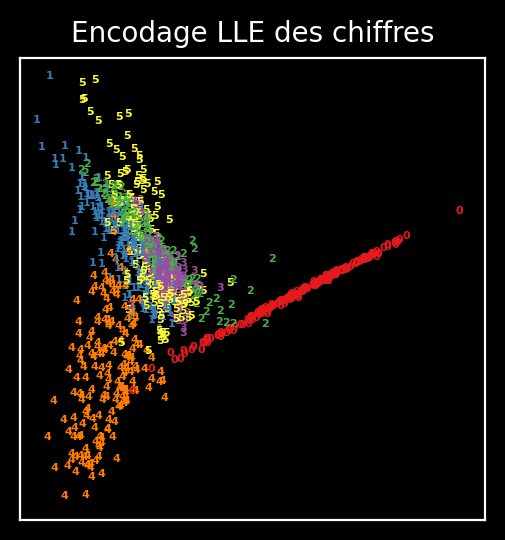

CPU times: user 1.26 s, sys: 27 ms, total: 1.29 s
Wall time: 683 ms


In [6]:
%%time
clf = manifold.LocallyLinearEmbedding(
    n_neighbors=n_neighbors,
    n_components=n_components,
    method='standard'
)

X_lle = clf.fit_transform(X)

plot_embedding(
    X_lle,
    y,
    title="Encodage LLE des chiffres"
)

Pas très convaincant dans ce cas-ci...

### Isomap

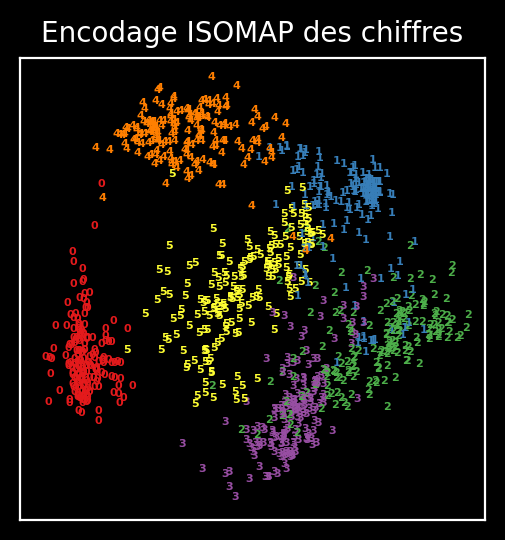

CPU times: user 3.06 s, sys: 44.9 ms, total: 3.11 s
Wall time: 1.07 s


In [7]:
%%time
iso = manifold.Isomap(
    n_neighbors=n_neighbors,
    n_components=n_components
)

X_iso = iso.fit_transform(X)

plot_embedding(
    X_iso,
    y,
    title="Encodage ISOMAP des chiffres"
)

Sépare mieux les classes que l'ACP, mais il y a toujours une recouvrement partiel des classes.

### *t-Distributed Stochastic Neighbor Embedding*
Cette méthode est connue sous le nom t-SNE.

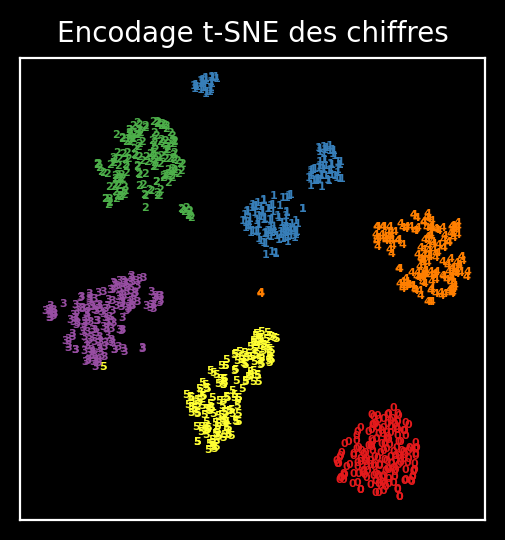

CPU times: user 9.72 s, sys: 22 ms, total: 9.74 s
Wall time: 1.51 s


In [8]:
%%time
tsne = manifold.TSNE(
    n_components=n_components,
    init='pca',
    random_state=seed,
    learning_rate='auto',
    perplexity=30,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    X_tsne = tsne.fit_transform(X)

plot_embedding(X_tsne, y, "Encodage t-SNE des chiffres")


La séparation des classes est excellente ; seules quelques données sont mal regroupées.

### *Uniform Manifold Approximation and Projection*
Cette méthode est connue sous le nom UMAP.

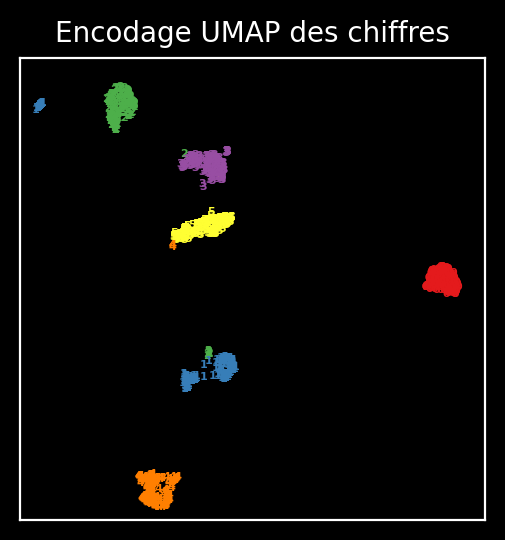

CPU times: user 8.41 s, sys: 36.8 ms, total: 8.44 s
Wall time: 7.41 s


In [9]:
%%time
umap_model = umap.UMAP(
    n_components=n_components,
    n_neighbors=n_neighbors,
    min_dist=0.1,
    metric="euclidean",
    random_state=seed,
)

X_umap = umap_model.fit_transform(X)

plot_embedding(X_umap, y, "Encodage UMAP des chiffres")

C'est la meilleure projection 2-D avec ce jeu de données. Non seulement les classes sont bien séparées, mais elles ont une faible dispersion interne; les nuages de points sont compacts. C'est une des méthodes les plus populaires
en ce moment. La séparation est rarement parfaite, mais elle est souvent meilleure que
celles obtenues avec les autres méthodes.

## Applications

Une application surprenante de la réduction de la dimensionnalité est l'aplatissement ou le déroulement
d'une surface 3-D sur une surface 2-D, par exemple sur une table. Nous allons en voir deux exemples.

Le code ci-dessous sert à afficher les graphiques.

In [10]:
def DerouleSurface3D(X, colors, n_neighbors=10):
    fig = plt.figure(figsize=(15, 8))
    fig.suptitle(
        f"Déroulement ou aplatissement de surface 3D avec {X.shape[0]} points, {n_neighbors} voisins",
        fontsize=14,
    )

    # --- Surface 3D dans le premier subplot ---
    ax = fig.add_subplot(231, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=colors, cmap=plt.cm.Spectral)
    ax.view_init(4, -72)
    ax.set_title("Surface 3D (vue 1)")

    # --- Méthodes utilisées ---
    LLE = partial(
        manifold.LocallyLinearEmbedding,
        n_components=2,
        n_neighbors=n_neighbors,
        eigen_solver='auto',
    )

    methods = OrderedDict()
    methods['PCA'] = decomposition.PCA(n_components=2)
    methods['LLE'] = LLE(method='standard')
    methods['Isomap'] = manifold.Isomap(n_components=2, n_neighbors=n_neighbors)
    methods['t-SNE'] = manifold.TSNE(n_components=2, init='pca', random_state=0)
    methods['UMAP'] = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        metric="euclidean",
        random_state=42,
    )

    # --- Affichage des projections 2D ---
    for i, (label, method) in enumerate(methods.items()):
        t0 = time()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Y = method.fit_transform(X)
        t1 = time()
        print(f"{label}: {t1 - t0:.2g} sec")

        # Subplots 232, 233, 234, 235, 236
        ax = fig.add_subplot(2, 3, 2 + i)
        ax.scatter(Y[:, 0], Y[:, 1], c=colors, cmap=plt.cm.Spectral)
        ax.set_title(label)
        ax.xaxis.set_major_formatter(NullFormatter())
        ax.yaxis.set_major_formatter(NullFormatter())
        ax.axis('tight')

    plt.show()

### Déroulement d'un rouleau suisse

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/vesuvius-scrolls.jpeg"  width="500" />
    <div>
    <font size="0.5">Image Source: https://allthatsinteresting.com/virtually-unravel-vesuvius-scrolls/</font>
    </div>
</div>

Voici une application de la réduction de dimensionnalité en archéologie. On utilise cette approche parmi
d'autres, pour dérouler des rouleaux de papyrus carbonisés! Un grand nombre d'entre eux ont
été trouvés dans une bibliothèque de la ville d'Herculanum détruite lors de l'éruption du Vésuve, en Italie,
en 79 A.D. Ils ont été imagés dans un scanneur CT (à rayons X) et on peut voir l'encre disposée en rouleau suisse
dans sa matrice carbonisée! On peut isoler les positions 3-D des zones d'encre puis utiliser plusieurs des
méthodes précédentes afin de projeter les zones d'encre en 2-D; on peut alors lire un papyrus carbonisé
il y a près de 2 000 ans! Comme dans bien des choses, le principe est simple, mais les détails sont complexes. Regardez la
[vidéo](https://youtu.be/PpNq2cFotyY) suivante pour vous donner une idée des défis à relever.

La figure suivante montre les résultats du déroulement du rouleau suisse obtenus en utilisant cinq des
méthodes présentées dans la première section. Le premier panneau montre la surface de départ et les autres
montrent les résultats du déroulement. Le code de couleur identifie les points voisins avant et après chaque
transformation. Un bon déroulement de la surface devrait conserver l'agencement local des couleurs.

Cet exemple s'inspire d'un exemple de code de la librairie
[Scikit-learn](https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html#sphx-glr-auto-examples-manifold-plot-compare-methods-py).

**Remarque**: variez le nombre de points et de voisins dans l'exemple suivant afin d'explorer les différents résultats. 

PCA: 0.00059 sec
LLE: 0.043 sec


Isomap: 0.37 sec


t-SNE: 1.9 sec


UMAP: 1.2 sec


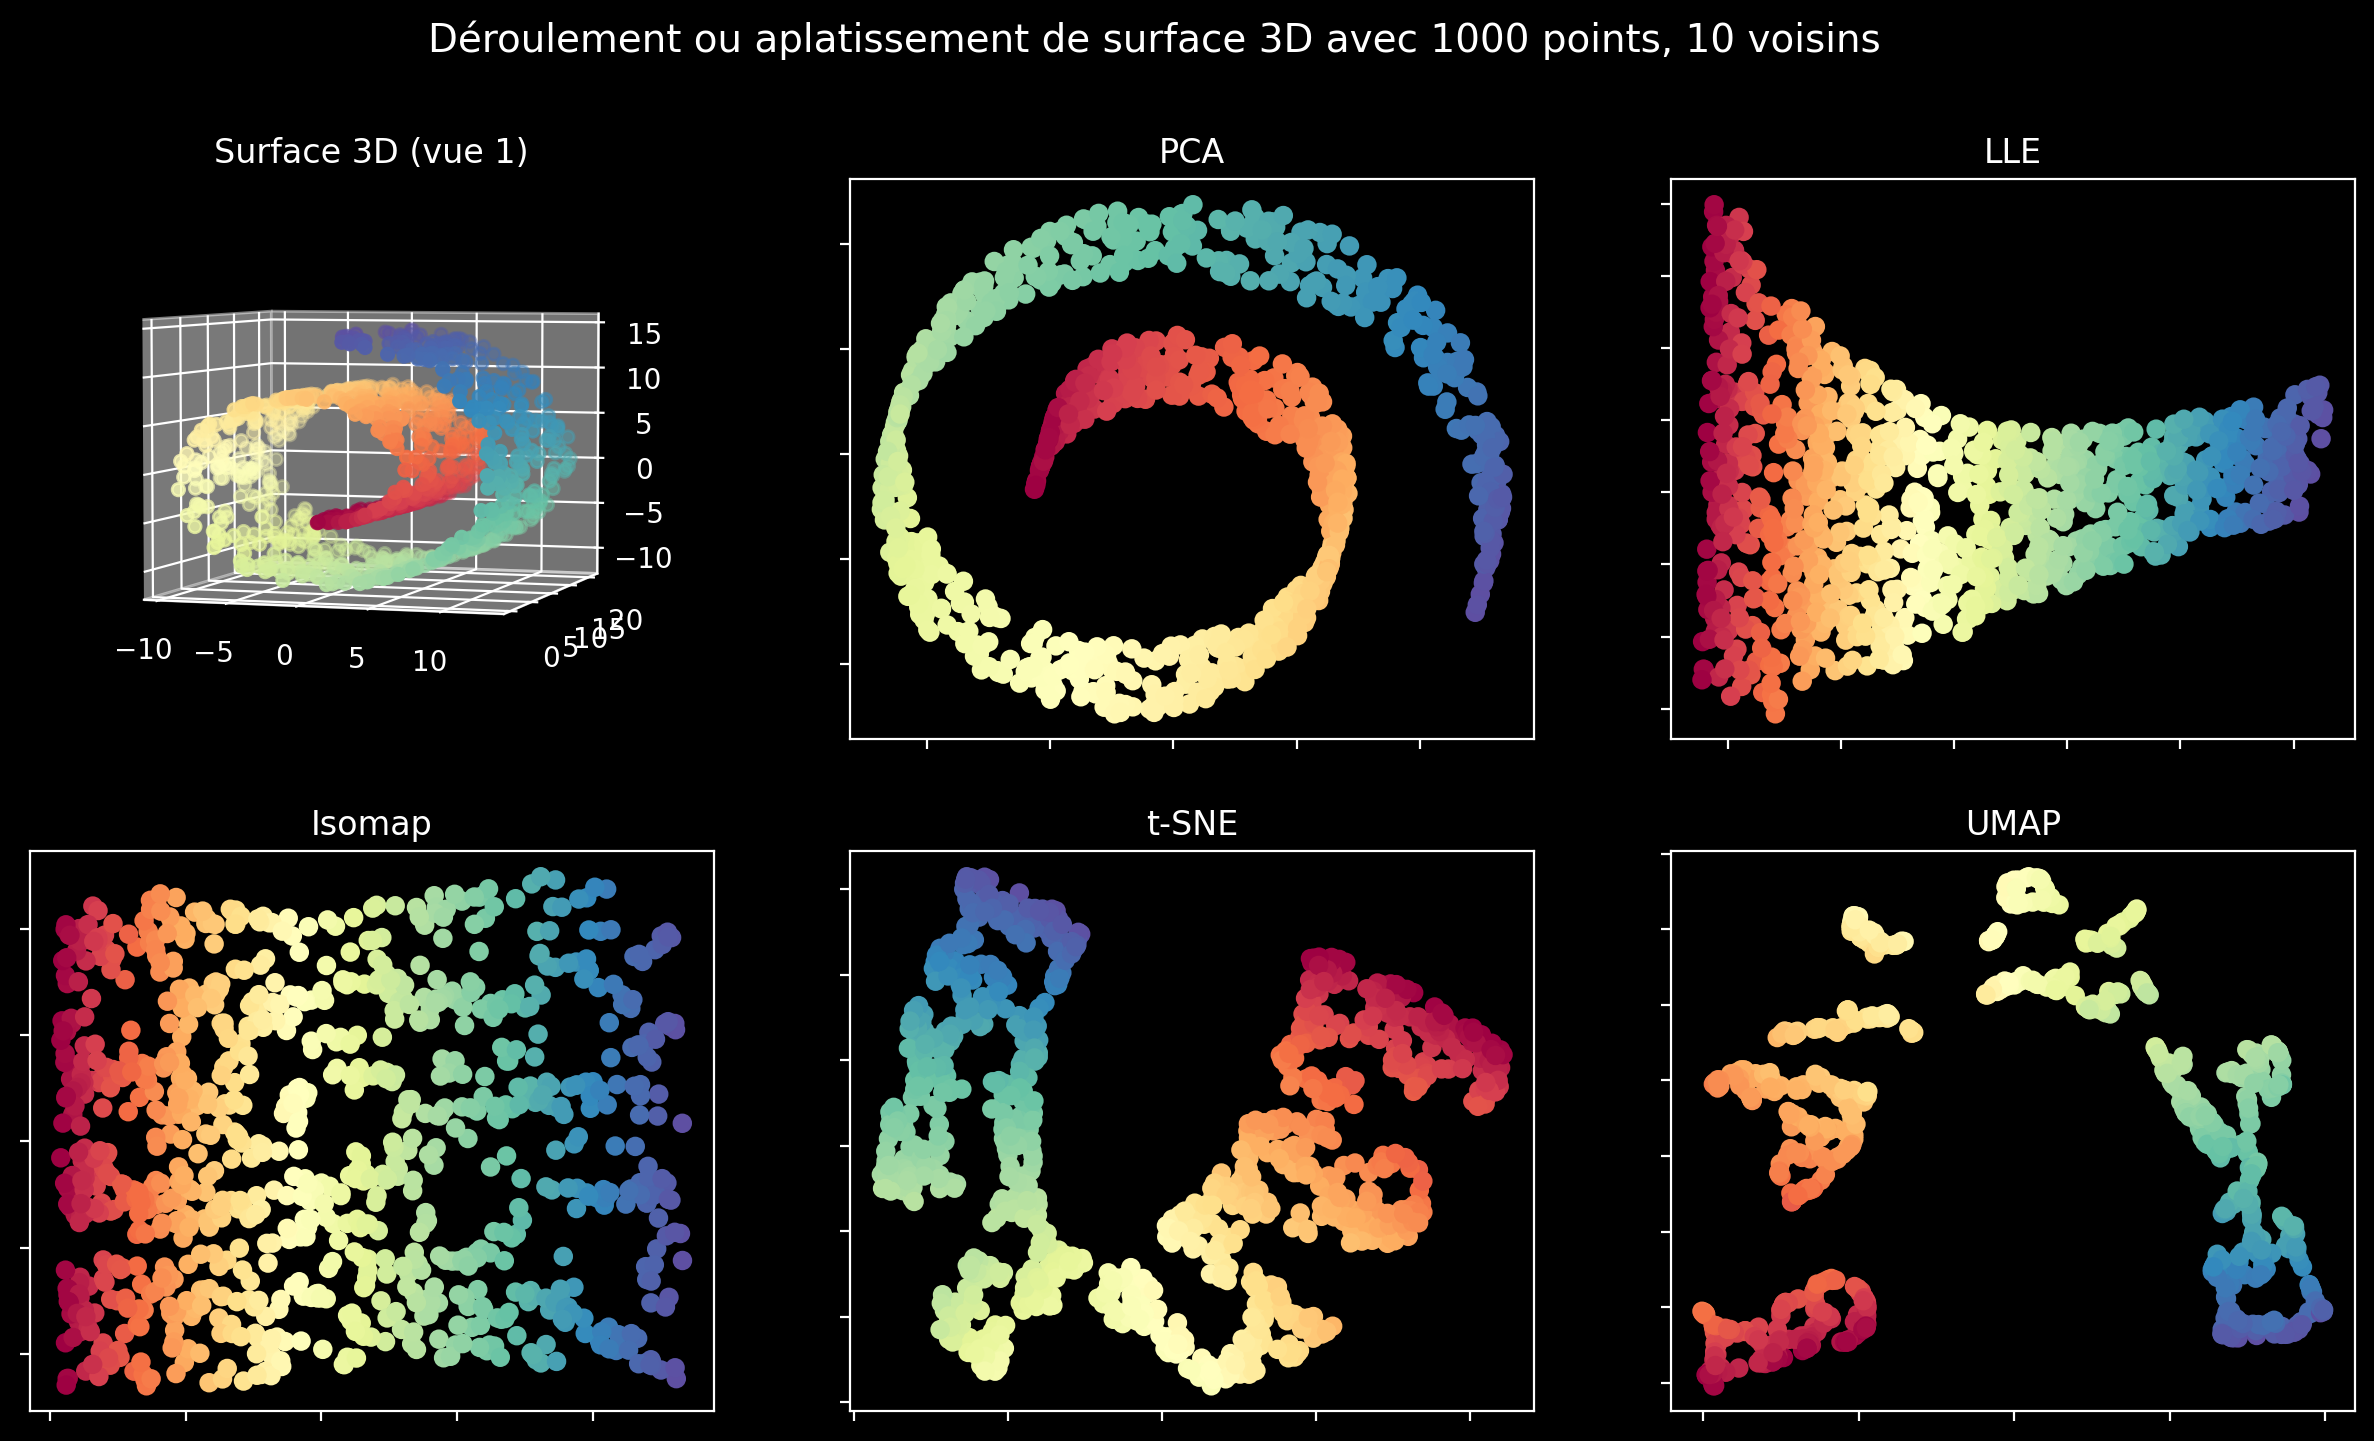

In [11]:
n_points = 1000
n_neighbors = 10

# Génération du rouleau suisse
X, couleurs = datasets.make_swiss_roll(n_points)

DerouleSurface3D(X, couleurs, n_neighbors)

Les méthodes LLE et Isomap produisent les meilleurs résultats. Notez que les méthodes t-SNE et UMAP, qui marchaient si bien
dans la section précédente, déchirent la bande en plusieurs sections.

La méthode Isomap devrait permettre de lire quelques sections d'un papyrus déroulé.

### Aplatissement d'une sphère manquant un quartier

À première vue, ça semble impossible à faire. Toutefois, il ne faut pas oublier que les méthodes de réduction de
dimensionnalité peuvent tordre les objets, comme on l'a vu dans l'exemple précédent. L'exemple qui suit
s'inspire d'un exemple de code de la librairie
[Scikit-learn](https://scikit-learn.org/stable/auto_examples/manifold/plot_manifold_sphere.html#sphx-glr-auto-examples-manifold-plot-manifold-sphere-py/).

**Remarque**: variez le nombre de points et de voisins dans l'exemple suivant afin d'explorer les différents résultats. 

PCA: 0.0013 sec


LLE: 0.24 sec


Isomap: 2.9 sec


t-SNE: 5.1 sec


UMAP: 4.9 sec


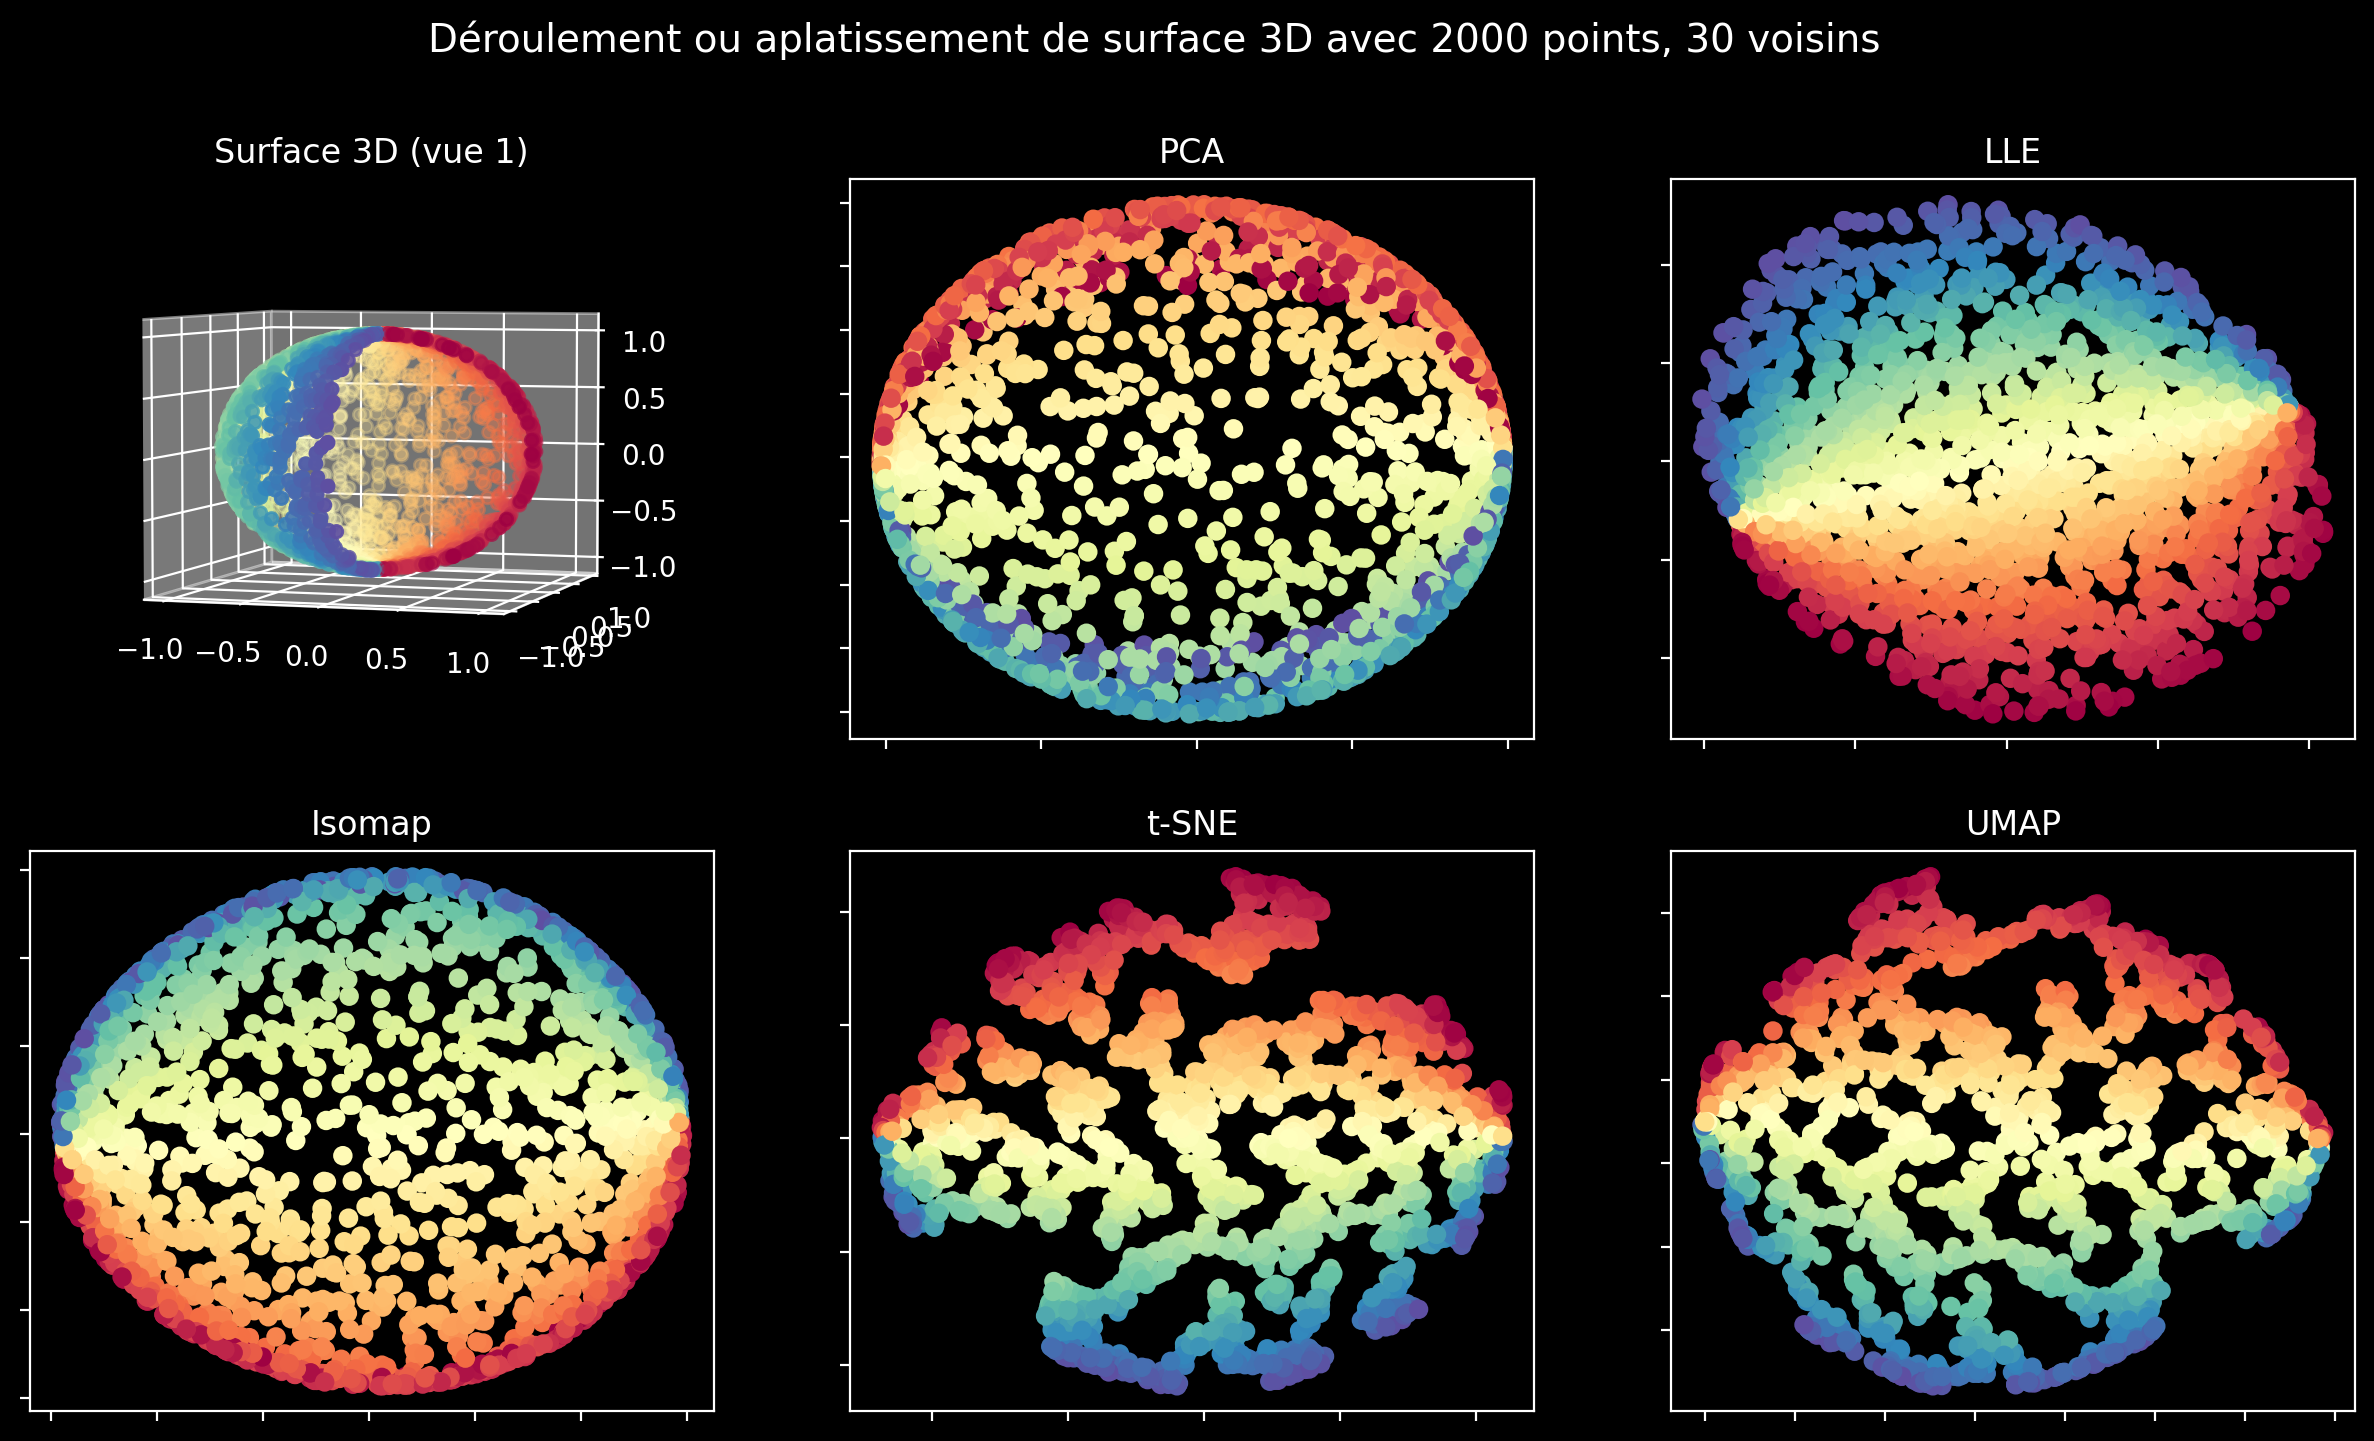

In [12]:
n_points = 2000
n_neighbors = 30

# Génération d'une sphère manquant un quartier
random_state = check_random_state(0)
phi = random_state.rand(n_points) * (1.5 * np.pi)
theta = random_state.rand(n_points) * np.pi

x, y, z = np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)

X = np.array([x, y, z]).T
couleurs = phi

DerouleSurface3D(X, couleurs, n_neighbors)

Toutes les méthodes, sauf t-SNE et UMAP qui la déchirent, réussissent à déformer localement la sphère 3-D afin
de la déplier sur un plan! La méthode LLE est celle qui fonctionne le mieux. C'est un exercice de topologie facile à réaliser.

Pensez-y un instant. Ces méthodes utilisent uniquement les notions de voisinage pour déformer des
surfaces complexes. Aucun modèle analytique de sphère ou de rouleau suisse n'est utilisé, sauf
pour générer les données initiales.

**Remarque**: libre à vous d'explorer de nouvelles formes (non fermées) à déformer!